PS. the system that I was working with a computer systemt that does not have GPU installed in it. So CPU was the only processer that I can utilise in this notbook, which is not a problem as we are working with simple CartPole example with pretty small neural networks. 

In [1]:
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from collections import namedtuple
from typing import Literal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
env = gym.make("CartPole-v1")
test_env = gym.make("CartPole-v1") # As a part of evaluation, we are running a test environment. To make sure that our evaluation is running on a completely separate environment from the training environment, I created two env variables.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
seed = 3088

random.seed(seed)
torch.manual_seed(seed)

env.reset(seed=seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [5]:
state, info = env.reset()
state_dim = len(state)
action_dim = env.action_space.n

In [6]:
class NN(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_count, output_dim, option: Literal["softmax", "normalise", None]):
        super(NN, self).__init__()

        layers = []
        # input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        #hidden layer
        if layer_count >= 2:
            for i in range(layer_count - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(nn.ReLU())
        #output layer
        layers.append(nn.Linear(hidden_dim, output_dim))
        if option=="softmax":
            layers.append(nn.Softmax(dim=-1))
        elif option=="normalise":
            layers.append(nn.BatchNorm1d(num_features=output_dim))
        
        self.model = nn.Sequential(*layers)

    def forward(self, X):
        return self.model(X)

In [7]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'terminal_flag'))

## Let's start from REINFORCE

According to the book "Deep Reinfrocement Learning Hands-On" by Maxim Lapan, the REINFORCE algorithm follows:
1. Initalise the network with random weights.
2. Play $N$ full episodes, saving their $(s,a,r,s')$ transitions
3. For every step, $t$, of every episode, $k$, calculate the discounted total reward for subsequent steps: $Q_{k,t}=\sum_{i=0}\gamma^ir_i$
4. Calculate the loss fucntion for all transitions: $L=-\sum_{k,t}Q_{k,t}log(\pi(s_{k,t},a_{k,t}))$
5. Perform an SGD update of weights, minimising the loss
6. repeat from step 2 unitl converged

In [8]:
REINFORCE = NN(state_dim, 128, 1, action_dim, option="softmax")
optimiser = optim.Adam(REINFORCE.parameters(), lr=0.01)
# I have learnt, from ChatGPT though..., that using Adam with decoupled weight decay (that is, AdamW) is not a convention in the field of RL. The primary answer from ChatGPT was that unlike supervised learning, the optimisation environment is dynamic in RL due to constant updating of policy and Q functions. So, historically the major successful RL baselines were built with RMSProp or Adam, so later work inherited those defaults. Also, mathematically the main advantage of AdamW is most useful in fixed-dataset supervised learning, while online RL has (i) changing data distribution, (ii) noisy targets, (iii) bootstrapping, and (iv) exploration-sensitive policies. Therefore, the nuance with AdamW on RL is mostly like "AdamW can work, but its main benefit is weaker in standard online RL, while its side effects can be more noticeable."

N = 64
TOT_EPISODE = N*1000
print(f"Total episode = {TOT_EPISODE}")
GAMMA = 0.99
testenv_reward_track = []
max_reward_log, min_reward_log = [], []

batch_discounted_reward_log, batch_probs_log = [], []

for i in tqdm(range(TOT_EPISODE)):
    done = False
    reward_log, prob_log = [], []
    
    state, info = env.reset()

    while not done:
        state = torch.Tensor(state)

        # In value-based RL, we work with probabilistic action functions, not the deterministic or epsilon-greedy method. Thus we need to calculate the probability distribution of all possible actions according to the state we are faced with, then sample one of the action from that probability distribution. 
        probs = REINFORCE(state)
        dist = Categorical(probs)
        action = dist.sample()
        prob = probs[action]

        state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        
        # According to the psuedo-code, we have to save the entire transitions, that is (s, a, r, s'). But as we can see in the psuedo-code the only element in the transition that we are actively using is the reward. The log probability of action (log(pi(a|s))) does not require us to save the state (s) and action (a) at all time instance, but just to save the probability of action (pi(a|s)) because we already calculated through the neural network. Thus we do not need to waste our memory, and just save the reward and prob.
        reward_log.append(reward)
        prob_log.append(dist.log_prob(action))

    temp_reward_log = []
    r = 0
    for j in reversed(range(len(reward_log))):
        r = reward_log[j] + GAMMA*r
        temp_reward_log.insert(0, r)
    batch_discounted_reward_log.extend(temp_reward_log)
    batch_probs_log.extend(prob_log)

    if (i+1)%N == 0:
        q = torch.Tensor(batch_discounted_reward_log)
        log_prob = torch.stack(batch_probs_log)
        
        # We perform standardisation on the discounted Returns. This crucial step is often omitted in purely theoretical pseudo-code.
        # The reason: In CartPole-v1, the agent receives a positive reward (+1) for every step it survives. Because all returns are strictly positive, the vanilla policy gradient theorem mathematically treats every sampled action as a "good" action that should increase in probability, just to varying degrees. Normalizing the returns acts as a baseline. It shifts the values so that "above average" actions remain positive (increasing their probability), while "below average" actions become negative (decreasing their probability).
        # In the book "Deep Reinforcement Learning Hands-On", it perform similar preprocess by subtracting the Q(s,a) by a constant value, which is called Baseline. In an essence, it is similar to what we are doing at the moment, but I just thought that standardisation makes more sense than simply subtracting by a random constant.
        q = (q - q.mean()) / (q.std() + 1e-9)

        multiplication = q*log_prob
        loss = -torch.sum(multiplication)

        loss.backward()
        optimiser.step()
        optimiser.zero_grad()

        batch_discounted_reward_log, batch_probs_log = [], []

        # I wanted to visualise something to pursuade that our agent is actually learning. To do so, for each update, we run the deterministic action selection and accumulate the reward such that we can calculate the total time step the agent survived. We run this "test environment" for 5 times and average it out. This average will indiacte if our agent have learnt to make action decision accordingly from the state.
        REINFORCE.eval()
        tot_reward_log = []
        with torch.no_grad():
            for k in range(10):
                tot_reward = 0.0
                test_state, info = test_env.reset()
                test_terminated, test_truncated = False, False
                while not (test_terminated or test_truncated):
                    test_prob, test_action = REINFORCE(torch.Tensor(test_state)).max(0)
                    test_state, test_reward, test_terminated, test_truncated, info = test_env.step(test_action.item())
                    tot_reward += float(test_reward)
                tot_reward_log.append(tot_reward)
        testenv_reward_track.append(np.mean(tot_reward_log))
        max_reward_log.append(np.max(tot_reward_log))
        min_reward_log.append(np.min(tot_reward_log))
        REINFORCE.train()

Total episode = 64000


100%|██████████| 64000/64000 [2:45:08<00:00,  6.46it/s]   


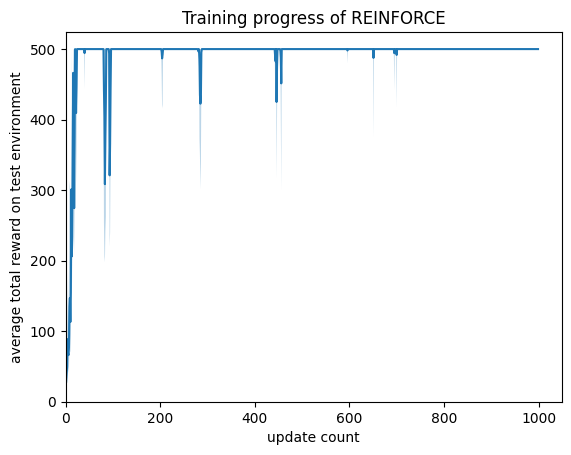

In [9]:
plt.plot(testenv_reward_track)
plt.fill_between(range(len(testenv_reward_track)),  min_reward_log, max_reward_log, alpha=0.3)
plt.xlabel("update count")
plt.ylabel("average total reward on test environment")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.title("Training progress of REINFORCE")
plt.show()

## Advantage Actor-Critic (A2C) Method
The Advantage Actor-Critic method, commonly known as A2C, follows the following psuedo-code.
1. Initialise network parameters, $\theta$, with random values
2. Play $N$ steps in the environment using the current policy, $\pi_\theta$, and saving the state, $s_t$, action, $a_t$, and reward, $r_t$
3. $R=0$ if the end of the episode is reached or $V_\theta(s_t)$
4. For $i=t-1, t-2, ..., t_{start}$ (note that steps are processed backward):
    - $R \larr r_i + \gamma R$
    - Accumulate the policy gradient: $\delta \theta_\pi \larr \delta \theta_\pi + \nabla log\pi_\theta (a_i|s_i)[R-V_\theta(s_i)]$
    - Accumulate the value gradient: $\delta\theta_v \larr \delta\theta_v + \delta(R - V_\theta(s_i))^2/\delta \theta_v$
5. Update the network parameters using the accumulated gradients, moving in the direction of the policy gradients, $\delta \theta_\pi$, and in the opposite direction of the value gradients, $\delta\theta_v$
6. Repeat from step 2 until convergence is reached.

In [10]:
# According to the A2C psuedo-code, it almost seems like that the policy and value function are completely separate. 
# However, according to the "Deep Reinfrocement Learning Hands-On", it states that often the two functions overlaps by a function called common network, or common body. 
# The author stated that it is mainly due to the efficiency and convergence. Considering, depite the fact that the CartPole problem is relatively eassy, this notebook primary serve as a sandbox practice for my own study, we will employ the common net in this example as well.

class A2CNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim, common_layer_num, layer_num, low_feature_dim, action_dim):
        super(A2CNetwork, self).__init__()

        common_layers = []
        common_layers.append(nn.Linear(state_dim, hidden_dim))
        common_layers.append(nn.ReLU())
        if common_layer_num >= 2:
            for i in range(common_layer_num - 1):
                common_layers.append(nn.Linear(hidden_dim, hidden_dim))
                common_layers.append(nn.ReLU())
        common_layers.append(nn.Linear(hidden_dim, low_feature_dim))
        common_layers.append(nn.ReLU())

        critic_layers = []
        critic_layers.append(nn.Linear(low_feature_dim, hidden_dim))
        critic_layers.append(nn.ReLU())
        if layer_num >= 2:
            for i in range(layer_num - 1):
                critic_layers.append(nn.Linear(hidden_dim, hidden_dim))
                critic_layers.append(nn.ReLU())
        critic_layers.append(nn.Linear(hidden_dim, 1))

        actor_layers = []
        actor_layers.append(nn.Linear(low_feature_dim, hidden_dim))
        actor_layers.append(nn.ReLU())
        if layer_num >= 2:
            for i in range(layer_num - 1):
                actor_layers.append(nn.Linear(hidden_dim, hidden_dim))
                actor_layers.append(nn.ReLU())
        actor_layers.append(nn.Linear(hidden_dim, action_dim))
        # I learnt that by taking this output into torch.distribution.Categorical(logit=output), we actually get very stable probability distribution rather than taking softmax here and input the softmax output as torch.distribution.Categorical(output). So we will use the logit method this time.

        self.common = nn.Sequential(*common_layers)
        self.critic = nn.Sequential(*critic_layers)
        self.actor = nn.Sequential(*actor_layers)

    def forward(self, X):
        low_features = self.common(X)
        action_logits = self.actor(low_features)
        state_value = self.critic(low_features)
        return action_logits, state_value

In [ ]:
a2c = A2CNetwork(state_dim=state_dim, hidden_dim=128, common_layer_num=2, layer_num=1, low_feature_dim=8, action_dim=action_dim)

# the default method of assigning the optimiser (ie. optimiser = optim.AdamW(a2c.parameters(), lr=1e-4)) has a critical issue. That is the fact that we cannot assign separate learning rate for actor and critic networks. So, it is almost necessary to define a dictionary of parameters and their own learning rates. It seems like, often we want our critic to learn faster than our actor, as out actor relie on the value estimation.
param_groups = [
    {'params': a2c.common.parameters(), 'lr': 1e-4},
    {'params': a2c.actor.parameters(),  'lr': 1e-4},
    {'params': a2c.critic.parameters(), 'lr': 1e-3}
]
optimiser = optim.Adam(param_groups)

GAMMA = 0.99
N = 64
TOT_N = N*40000

reward_log, value_log, log_prob_log, terminal_flag_log = [], [], [], []
testenv_reward_track = []
max_reward_log, min_reward_log = [], []

state, info = env.reset()
# One of the thing to point out is that the REINFORCE algorthm required us to run N full episodes. But for A2C algorithm, we only had to run N steps then update our networks, no matter whether the episode is done for the algorithm to be updated. I guess we could make the algorithm to update either when it hits N steps or hits the end of episode, but just to keep it simple, I only updated every N steps.
for i in tqdm(range(TOT_N)):
    state = torch.Tensor(state)
    action_logits, value = a2c(state)

    probs = Categorical(logits=action_logits)
    action = probs.sample()
    log_prob = probs.log_prob(action)

    state, reward, terminated, truncated, info = env.step(action.item())
    terminal_condition = terminated or truncated

    # Although the psuedo-code explicitly mentioned to save the state, but the actual values that are actively used in the gradient calculation is discounted reward, value, and log(pi).
    reward_log.append(reward)
    value_log.append(value)
    log_prob_log.append(log_prob)
    terminal_flag_log.append(terminal_condition) # the variable R at step 3 and 4 is the sum of discounted future reward (ie, discounted return). But the terminal state has no such thing as "future", thus R=0 for terminal state and the R must be reinitialised for the new episode.

    if (i+1)%N == 0:
        q = []
        if terminal_condition:
            r = 0.0
        else:
            r = a2c(torch.Tensor(state))[1].item()

        for j in reversed(range(len(reward_log))):
            r = reward_log[j] + GAMMA*r*(1 - terminal_flag_log[j])
            q.insert(0, r)

        q_batch = torch.Tensor(q)
        pi_batch = torch.stack(log_prob_log)
        v_batch = torch.stack(value_log).squeeze()

        advantage = q_batch - v_batch
        advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)

        # 1. In practical view, it is important to perform advantage.detach() for policy loss calculation. Without this ".detach()" essentially, the policy loss can also back propagare into the critic network as advantage is calculated as pi_log - v_log and the v_log itself holds the graph information of the critic network. So, by performing advantage.detach() for policy loss calculation, we can only let the policy gradient to be backpropagated into the common network and policy network, only.
        # 2. According to pseudo-code, it only talks about accumulating the gradient rathern than taking mean of the loss. This is becasue, the pseudo-code is describing the mathematical gradient accumulation, not prescribing the exact scalar loss reduction. If we implement that pseudo-code literallty, then taking sum of the loss is the actual direct translation. But according to the book, it is taking mean to calculate the update and weights. I guess, this is one of the stabilisation technique, as this keeps the gradient subtle as it can by ensuring that the gradient does not growing proportional to the batch size.
        actor_loss = -torch.mean(advantage.detach()*pi_batch)
        critic_criterion = nn.MSELoss()
        critic_loss = critic_criterion(q_batch, v_batch)

        actor_loss.backward(retain_graph=True)
        critic_loss.backward()
        optimiser.step()
        optimiser.zero_grad()
        
        reward_log.clear()
        value_log.clear()
        log_prob_log.clear()
        terminal_flag_log.clear()

        a2c.eval()
        tot_reward_log = []
        with torch.no_grad():
            for k in range(10):
                tot_reward = 0.0
                test_state, info = test_env.reset()
                test_terminated, test_truncated = False, False
                while not (test_terminated or test_truncated):
                    test_action_logit, value = a2c(torch.Tensor(test_state))
                    test_action = torch.argmax(test_action_logit).detach().cpu().numpy()
                    test_state, test_reward, test_terminated, test_truncated, info = test_env.step(test_action)
                    tot_reward += float(test_reward)
                tot_reward_log.append(tot_reward)
        testenv_reward_track.append(np.mean(tot_reward_log))
        max_reward_log.append(np.max(tot_reward_log))
        min_reward_log.append(np.min(tot_reward_log))
        a2c.train()

    if terminal_condition:
        state, info = env.reset()

100%|██████████| 2560000/2560000 [5:00:04<00:00, 142.19it/s]  


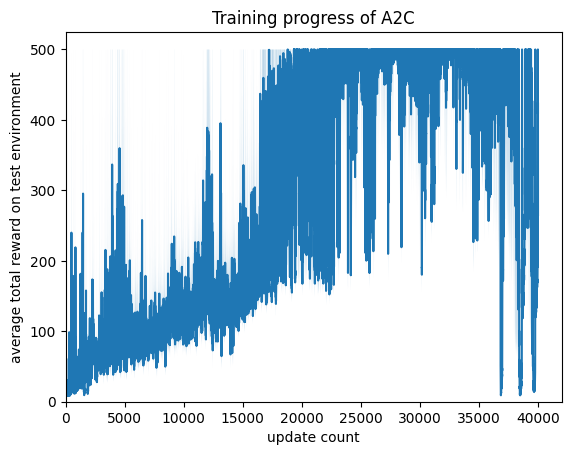

In [12]:
plt.plot(testenv_reward_track)
plt.fill_between(range(len(testenv_reward_track)),  min_reward_log, max_reward_log, alpha=0.3)
plt.xlabel("update count")
plt.ylabel("average total reward on test environment")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.title("Training progress of A2C")
plt.show()

As we can see from the code, the A2C implemented here is raw algorithm that only have the very core ideas of A2C. Thus, there is no stabiliser acting in the algorithm. We could add gradient clipping, entropy bonus, adtangae normalization, value loss coefficient tuning, and more to stabilise our training. This is directly reflected in the evaluatio curve, where the evaluation score does show up-right movement in genenral, but very noisy. Becasue this notebook's sole purpose is to learn the policy-based RL, I just want to keep everything simple and focus on building the very core ideas of each algorithm.<br>
<br>Moreover, one of the significant problem at the moment with this A2C algorithm is that it is experiencing policy collapse (,or catastrophuc forgetting). I guess this is not due to the problem of the A2C algorithm, but more to do with the instability in the training loop. 

## Finally, PPO
According to the book, it states the majoe changes of PPO from A2C algorithm are followings<br>
<br>Firstly, the objective function got changed from $$J_\theta = \mathbb{E}_t[\nabla_\theta log\pi_\theta(a_t|s_t)A_t]$$ to $$J_\theta^{clip} = \mathbb{E}_t[\min(r_t(\theta)A_t, clip(r_t(\theta), 1-\epsilon, 1+\epsilon)A_t)]$$ $$r_t(\theta) = {\pi_\theta(a_t|s_t)}/{\pi_{\theta,old}(a_t|s_t)}$$<br>
<br>Secondly, the advantage estimation have changed. For A2C, the advantage is estimated as $$A(a_t,s_t) = Q(a_t,s_t) - V(s_t)$$ $$Q(a_t,s_t) = r_t + \gamma r_{t-1} + \gamma^2 r_{t-2} + ... + \gamma^{T-t+1} r_{T-1} + \gamma^{T-t} V(s_t)$$ However, for PPO algorithm the advantage is estimated as following $$A(a_t,s_t) = \sigma_t + (\gamma\lambda)\sigma_{t+1} + (\gamma\lambda)^2\sigma_{t+2} + ... + (\gamma\lambda)^{T-t+1}\sigma_{T-1}$$ $$\sigma_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$ This updated advantage estimation method is called generalised advantage estimator.<br>
<br>Lastly, the training method of PPO is also unique, compared to previously seen on-policy methods. The PPO gather a long sequence of samples from environment and then the advantage is estimated for the whole sequence before several epoches of training are performed.

In [ ]:
PPO = A2CNetwork(state_dim, 128, 1, 1, 8, action_dim)
param_groups = [
    {'params': PPO.common.parameters(), 'lr': 1e-5},
    {'params': PPO.actor.parameters(),  'lr': 1e-5},
    {'params': PPO.critic.parameters(), 'lr': 1e-4}
]
optimiser = optim.Adam(param_groups)

MAX_EPISODE = 60000
UPDATE_N = 2048
GAMMA = 0.99
LAMBDA = 0.95
EPSILON = 0.2
EPOCHES = 10
BATCH_SIZE = 64

n = 0
transitions, old_pi = [], []
for _ in tqdm(range(MAX_EPISODE)):
    state, info = env.reset()
    done = False
    while not done:
        state = torch.Tensor(state)
        with torch.no_grad(): # torch.no_grad() is required in PPO, as we are not trying to calculate the gradient from this rollout. In PPO, the pi_old is treated as a constant not variable.
            action_logits, state_value = PPO(state)

            prob = Categorical(logits=action_logits)
            action = prob.sample()
            old_pi.append(prob.log_prob(action))

        next_state, reward, terminated, truncated, info = env.step(action.item())
        n += 1
        done = terminated or truncated
        # From the book, I learnt that it is convention to acquire the V(s) via using state and network, rather than saving its value into a list. So decided to use transition this time.
        transition = Transition(state, action, reward, next_state, done) 
        transitions.append(transition)

        if n % UPDATE_N == 0:
            batch = Transition(*zip(*transitions))
            transitions.clear()

            batch_state      = torch.stack(batch.state)
            batch_action     = torch.stack(batch.action)
            batch_reward     = torch.Tensor(batch.reward)
            batch_next_state = torch.Tensor(torch.stack([torch.Tensor(s) for s in batch.next_state]))
            batch_done       = torch.Tensor([float(d) for d in batch.terminal_flag])

            with torch.no_grad():
                _, batch_values      = PPO(batch_state)
                _, batch_next_values = PPO(batch_next_state)
                batch_values      = batch_values.squeeze()
                batch_next_values = batch_next_values.squeeze()

            adv, ret = 0, 0.0
            advantages, returns = [], []
            for t in reversed(range(len(batch_reward))):
                if batch_done[t]:
                    delta = batch_reward[t] - batch_values[t]
                    adv = delta
                    ret = 0.0
                else:
                    delta = batch_reward[t] + GAMMA * batch_next_values[t] - batch_values[t]
                    adv = delta + GAMMA * LAMBDA * adv
                advantages.append(adv)
                ret = batch_reward[t] + GAMMA * ret
                returns.append(ret)

            advantages.reverse()
            returns.reverse()
            advantages = torch.Tensor(advantages)
            returns = torch.Tensor(returns)

            returns = advantages + batch_values
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            old_log_probs = torch.stack(old_pi[:len(batch_reward)]).detach()
            old_pi.clear()

            dataset_size = len(batch_reward)
            for epoch in range(EPOCHES):
                # Shuffle indices each epoch
                indices = torch.randperm(dataset_size)

                for start in range(0, dataset_size, BATCH_SIZE):
                    idx = indices[start : start + BATCH_SIZE]

                    mb_state     = batch_state[idx]
                    mb_action    = batch_action[idx]
                    mb_advantage = advantages[idx]
                    mb_return    = returns[idx]
                    mb_old_lp    = old_log_probs[idx]

                    # Fresh forward pass — this one builds the graph for backprop
                    action_logits, values = PPO(mb_state)
                    values = values.squeeze()

                    prob       = Categorical(logits=action_logits)
                    new_log_prob = prob.log_prob(mb_action)

                    # PPO clipped objective
                    ratio       = torch.exp(new_log_prob - mb_old_lp)
                    clipped     = torch.clamp(ratio, 1 - EPSILON, 1 + EPSILON)
                    actor_loss  = -torch.min(ratio * mb_advantage, clipped * mb_advantage).mean()

                    critic_loss = nn.MSELoss()(mb_return.detach(), values)

                    total_loss = actor_loss + critic_loss

                    optimiser.zero_grad()
                    total_loss.backward()
                    optimiser.step()

            PPO.eval()
            tot_reward_log = []
            with torch.no_grad():
                for _ in range(10):
                    tot_reward = 0.0
                    test_state, info = test_env.reset()
                    test_terminated, test_truncated = False, False
                    while not (test_terminated or test_truncated):
                        test_action_logit, value = PPO(torch.Tensor(test_state))
                        test_action = torch.argmax(test_action_logit).detach().cpu().numpy()
                        test_state, test_reward, test_terminated, test_truncated, info = test_env.step(test_action)
                        tot_reward += float(test_reward)
                    tot_reward_log.append(tot_reward)
            testenv_reward_track.append(np.mean(tot_reward_log))
            max_reward_log.append(np.max(tot_reward_log))
            min_reward_log.append(np.min(tot_reward_log))
            PPO.train()
                    
        state = next_state

100%|██████████| 60000/60000 [1:06:43<00:00, 14.99it/s] 


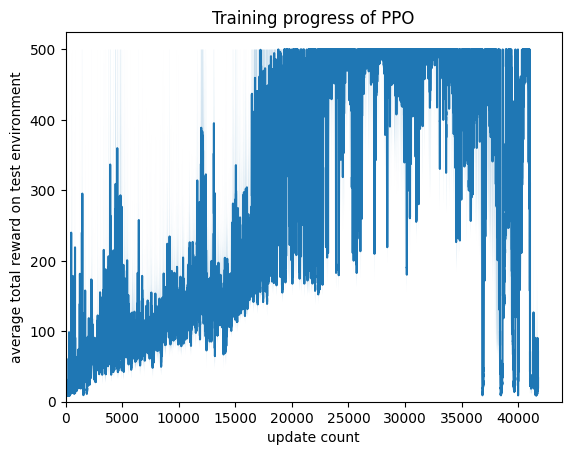

In [15]:
plt.plot(testenv_reward_track)
plt.fill_between(range(len(testenv_reward_track)),  min_reward_log, max_reward_log, alpha=0.3)
plt.xlabel("update count")
plt.ylabel("average total reward on test environment")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.title("Training progress of PPO")
plt.show()